In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
np.random.seed(0)

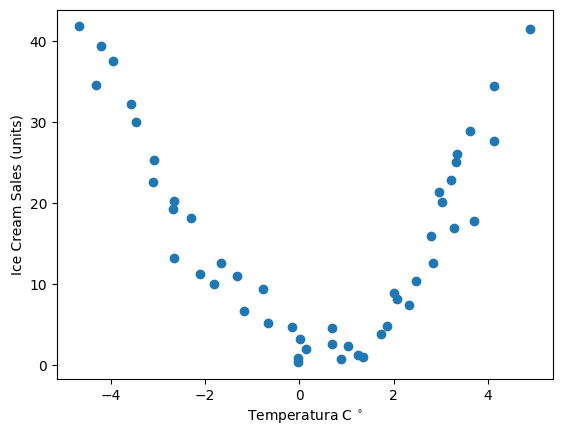

In [80]:
df = pd.read_csv("Ice_creamSellingData.csv", skiprows=1, header=None)
y = df.iloc[:, 1].values.reshape(-1, 1) # Sales unidades
x = df.iloc[:, 0].values.reshape(-1, 1) # temperatura 
plt.scatter(x,y)
plt.xlabel("Temperatura C $^{\\circ}$")
plt.ylabel("Ice Cream Sales (units)")
plt.show()

In [81]:
def evaluate_polynomial_models(X, y, max_degree=10):
    degrees = range(1, max_degree + 1)
    train_scores = []
    cv_scores = []
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=0)
    
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree)
        x_poly2 = poly.fit_transform(x)
        model = LinearRegression()
        model.fit(x_poly2, y)
        
        score = model.score(x_poly2,y)
        train_scores.append(score)
        cv_score = cross_val_score(model, x_poly2, y, cv=kfold, 
                                 scoring='r2')
        cv_scores.append(cv_score.mean())
    
    return degrees, train_scores, cv_scores   

def plot_cv_results(degrees, train_scores, cv_scores):
    plt.figure(figsize=(10, 6))
    plt.plot(degrees, train_scores, 'o-', label='Entrenamiento', color='blue')
    plt.plot(degrees, cv_scores, 'o-', label='Cross-Validation', color='red')
    plt.xlabel('Grado del Polinomio')
    plt.ylabel('$R^2$ score')
    plt.title('Curvas de Aprendizaje - Cross Validation')
    plt.legend()
    plt.grid(True)
    plt.show()

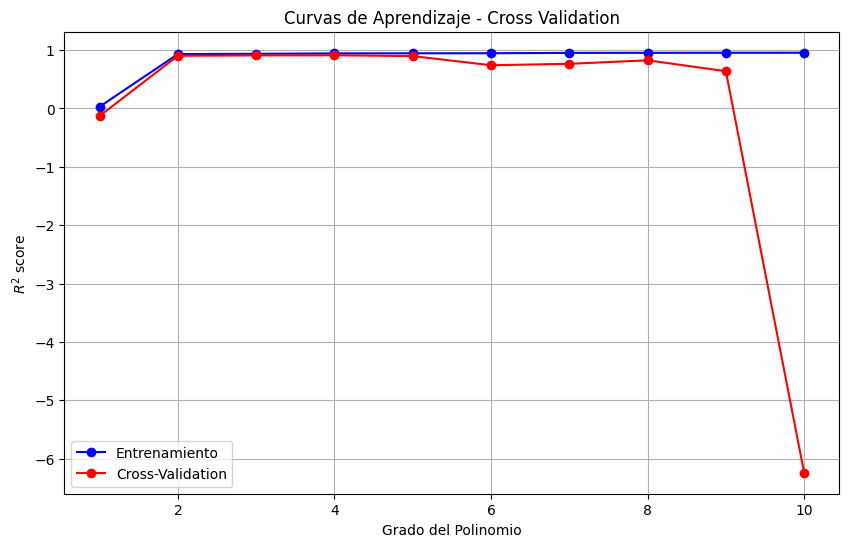

In [82]:
degrees, train_scores, cv_scores = evaluate_polynomial_models(x, y, max_degree=10)
plot_cv_results(degrees, train_scores, cv_scores)